<a href="https://colab.research.google.com/github/Ahmadbhi/Multiclass-logistic-Regression/blob/main/Multiclass_Logistic_Regression_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.69      0.82        13
           2       0.76      1.00      0.87        13

    accuracy                           0.91        45
   macro avg       0.92      0.90      0.89        45
weighted avg       0.93      0.91      0.91        45

Confusion Matrix:
 [[19  0  0]
 [ 0  9  4]
 [ 0  0 13]]
Accuracy Score:  0.9111111111111111


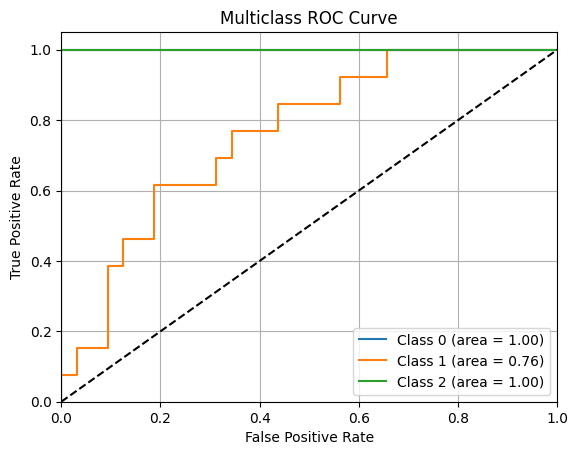

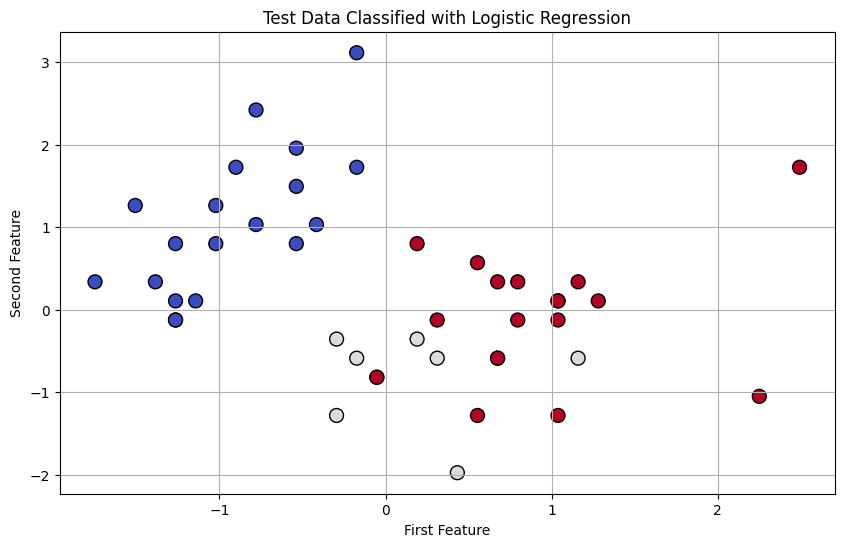

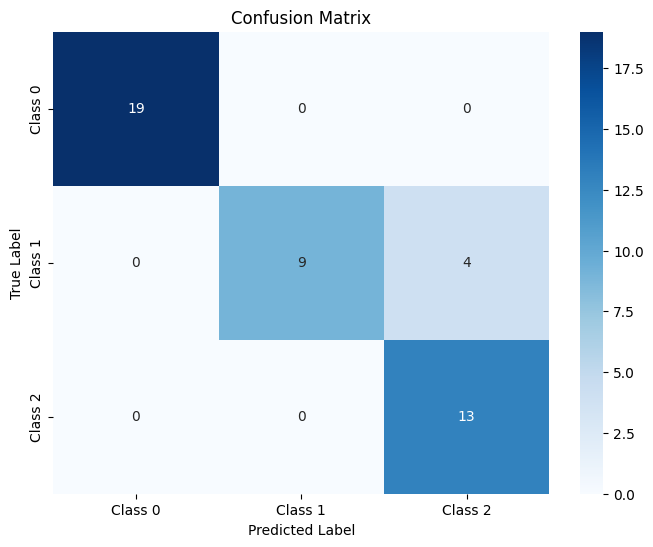

Would you like to predict a new record? (y/n): y
Enter Sepal Length: 10
Enter Sepal Width: 20
Enter Petal Length: 34
Enter Petal Width: 78
Predicted class: 2 (0: Setosa, 1: Versicolour, 2: Virginica)
Would you like to predict a new record? (y/n): n
Exiting the prediction loop.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
import seaborn as sns

# Step 1: Load and Preprocess the Iris dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv(url, header=None, names=columns)

# Step 2: Encode the target variable (species) into numerical format
df['species'] = df['species'].astype('category').cat.codes

# Split the features and target
X = df.drop('species', axis=1)
y = df['species']

# Step 3: Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Step 5: Apply Multiclass Logistic Regression
model = OneVsRestClassifier(LogisticRegression(solver='lbfgs', max_iter=200))
model.fit(X_train, y_train)

# Step 6: Predict the testing data
y_pred = model.predict(X_test)

# Step 7: Evaluate the model's performance
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score: ", accuracy_score(y_test, y_pred))

# Step 8: Calculate ROC AUC score
y_bin = label_binarize(y, classes=[0, 1, 2])
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = model.decision_function(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve
for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (area = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Step 9: Visualize the data and classification decision boundaries
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap="coolwarm", s=100, edgecolors='k')
plt.title("Test Data Classified with Logistic Regression")
plt.xlabel("First Feature")
plt.ylabel("Second Feature")
plt.grid(True)
plt.show()

# Step 10: Assuming you have true labels (y_test) and predicted labels (y_pred)
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Step 11: Create a loop for predicting new records
while True:
    user_input = input("Would you like to predict a new record? (y/n): ")
    if user_input.lower() == 'n':
        print("Exiting the prediction loop.")
        break
    elif user_input.lower() == 'y':
        try:
            sepal_length = float(input("Enter Sepal Length: "))
            sepal_width = float(input("Enter Sepal Width: "))
            petal_length = float(input("Enter Petal Length: "))
            petal_width = float(input("Enter Petal Width: "))

            # Convert input to DataFrame for compatibility with StandardScaler
            new_data = pd.DataFrame([[sepal_length, sepal_width, petal_length, petal_width]], columns=columns[:-1])

            # Normalize the new input
            new_data_scaled = scaler.transform(new_data)
            prediction = model.predict(new_data_scaled)

            print(f"Predicted class: {prediction[0]} (0: Setosa, 1: Versicolour, 2: Virginica)")
        except ValueError:
            print("Invalid input. Please enter numeric values for the features.")
    else:
        print("Invalid input. Please type 'y' for yes or 'n' for no.")